In [38]:
import torch
import tiktoken
import torch.nn.functional as F
enc=tiktoken.get_encoding('gpt2')
import math
import matplotlib.pyplot as plt


In [2]:
text="The cat sat on the mat"
tokens=enc.encode(text)
input_tokens=torch.tensor((tokens))
print(input_tokens)


tensor([ 464, 3797, 3332,  319,  262, 2603])


In [3]:
torch.manual_seed(42)
tok_emb_table=torch.randn((50257,8))
Wq=torch.randn((8,8))
Wk=torch.randn((8,8))
Wv=torch.randn((8,8))

In [6]:
one_query_vector = tok_emb_table[input_tokens[0]] @ Wq
print(one_query_vector)

tensor([-6.5053, -1.9255, -0.0308, -4.8382,  1.3157,  2.7127, -1.0828,  3.4454])


In [7]:
key_vectors=tok_emb_table[input_tokens] @ Wk
print(key_vectors)

tensor([[ 1.7266, -2.2271, -4.0587,  1.1727, -0.7295,  1.9768, -1.0774, -1.7233],
        [-1.6037, -2.8537, -5.7860, -0.5970,  0.5474,  2.6014, -1.8175,  0.1838],
        [-2.4480, -5.1382, -5.0363, -1.2532, -0.5942,  5.7421, -1.8565, -5.5233],
        [-3.4642, -1.2263, -1.7874, -3.5045, -1.5615,  0.6953, -2.6274,  0.5493],
        [-2.4848, -0.7995, -0.5524,  0.6294,  4.7078,  2.3520, -2.3717, -0.5327],
        [-1.8926, -0.2385,  0.7608, -0.5784,  0.6980, -0.0068, -0.0403,  0.2963]])


In [8]:
attention_vector_for_single_query= one_query_vector @ key_vectors.transpose(0,1)
print(attention_vector_for_single_query)

tensor([-12.8603,  29.3725,  29.8121,  46.4773,  27.9831,  17.5103])


In [25]:
attention_scores_for_single_query = F.softmax(attention_vector_for_single_query)
torch.set_printoptions(sci_mode=True)
print(attention_scores_for_single_query)

tensor([1.6981e-26, 3.7277e-08, 5.7860e-08, 1.0000e+00, 9.2905e-09, 2.6289e-13])


/var/folders/nj/l7xpbbbj64jdjzwnvz7txmpr0000gn/T/ipykernel_2209/1089693264.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  attention_scores_for_single_query = F.softmax(attention_vector_for_single_query)


In [13]:
value_vectors=tok_emb_table[input_tokens] @ Wv
final_output_vectors = attention_scores_for_single_query @ value_vectors
print(final_output_vectors)

tensor([ 0.9242916703, -3.5429947376, -1.4211302996, -1.2426956892,
        -3.5648446083, -1.6992268562, -1.9202986956,  4.0291357040])


In [27]:
query_vectors=tok_emb_table[input_tokens] @ Wq
torch.set_printoptions(precision=4,sci_mode=False)
print(query_vectors)

tensor([[ -6.5053,  -1.9255,  -0.0308,  -4.8382,   1.3157,   2.7127,  -1.0828,
           3.4454],
        [ -6.7435,   5.2253,  -0.6423,  -0.2889,  -0.4064,   3.4917,  -3.1876,
           0.8432],
        [-10.4665,  -3.0995,   1.9680,  -0.2772,  -2.5634,   3.5175,  -1.1113,
           4.0042],
        [ -0.2177,   1.4900,  -1.3366,  -0.5143,  -0.4036,   1.3058,  -1.0725,
           2.8986],
        [ -0.8147,   0.8236,  -1.9007,   3.7237,  -2.1394,   2.4140,   0.2518,
           0.6205],
        [  0.9059,   3.2990,   1.0095,   3.9357,  -1.4844,  -0.7652,  -0.6196,
          -1.8908]])


In [28]:
print(key_vectors)

tensor([[ 1.7266, -2.2271, -4.0587,  1.1727, -0.7295,  1.9768, -1.0774, -1.7233],
        [-1.6037, -2.8537, -5.7860, -0.5970,  0.5474,  2.6014, -1.8175,  0.1838],
        [-2.4480, -5.1382, -5.0363, -1.2532, -0.5942,  5.7421, -1.8565, -5.5233],
        [-3.4642, -1.2263, -1.7874, -3.5045, -1.5615,  0.6953, -2.6274,  0.5493],
        [-2.4848, -0.7995, -0.5524,  0.6294,  4.7078,  2.3520, -2.3717, -0.5327],
        [-1.8926, -0.2385,  0.7608, -0.5784,  0.6980, -0.0068, -0.0403,  0.2963]])


In [29]:
query_key_vectors = query_vectors @ key_vectors.transpose(0,1)
print(query_key_vectors)

tensor([[-12.8603,  29.3725,  29.8121,  46.4773,  27.9831,  17.5103],
        [-11.8328,  14.6005,  14.8075,  31.0150,  26.1619,  11.2659],
        [-16.3608,  24.9111,  33.6513,  49.0814,  23.9318,  21.6233],
        [  0.1637,   9.7960,  -6.0275,   9.0672,   1.9351,  -0.0513],
        [ 13.8324,  12.4959,  13.9071,  -3.1411,  -0.5620,  -3.5901],
        [ -1.7689, -21.0822, -21.1025, -20.4055,  -9.2801,  -5.5757]])


In [30]:
normalized_query_key_vectors=query_key_vectors/math.sqrt(query_vectors.size(-1))
print(normalized_query_key_vectors)

tensor([[-4.5468, 10.3847, 10.5402, 16.4322,  9.8935,  6.1908],
        [-4.1835,  5.1621,  5.2352, 10.9655,  9.2496,  3.9831],
        [-5.7844,  8.8074, 11.8975, 17.3529,  8.4612,  7.6450],
        [ 0.0579,  3.4634, -2.1310,  3.2057,  0.6842, -0.0181],
        [ 4.8905,  4.4180,  4.9169, -1.1105, -0.1987, -1.2693],
        [-0.6254, -7.4537, -7.4609, -7.2144, -3.2810, -1.9713]])


In [32]:
softmax_normalized_query_key_vectors=F.softmax(normalized_query_key_vectors,dim=-1)
torch.set_printoptions(sci_mode=True)
print(softmax_normalized_query_key_vectors)

tensor([[7.6923e-10, 2.3483e-03, 2.7432e-03, 9.9344e-01, 1.4369e-03, 3.5429e-05],
        [2.2204e-07, 2.5419e-03, 2.7349e-03, 8.4246e-01, 1.5149e-01, 7.8189e-04],
        [8.9037e-11, 1.9352e-04, 4.2536e-03, 9.9536e-01, 1.3689e-04, 6.0520e-05],
        [1.7444e-02, 5.2560e-01, 1.9544e-03, 4.0621e-01, 3.2632e-02, 1.6168e-02],
        [3.7581e-01, 2.3429e-01, 3.8586e-01, 9.3058e-04, 2.3161e-03, 7.9397e-04],
        [7.4957e-01, 8.1158e-04, 8.0577e-04, 1.0309e-03, 5.2661e-02, 1.9512e-01]])


In [33]:
final_value_matrix= softmax_normalized_query_key_vectors @ value_vectors
print(final_value_matrix)

tensor([[ 9.2200e-01, -3.5276e+00, -1.4121e+00, -1.2289e+00, -3.5519e+00,
         -1.7033e+00, -1.9138e+00,  3.9996e+00],
        [ 8.2636e-01, -2.4861e+00, -1.6467e+00, -7.4044e-01, -3.9431e+00,
         -1.1675e+00, -1.7623e+00,  3.7042e+00],
        [ 9.1692e-01, -3.5342e+00, -1.4078e+00, -1.2305e+00, -3.5460e+00,
         -1.7046e+00, -1.9205e+00,  3.9942e+00],
        [ 1.6678e+00, -3.1309e+00, -7.9860e-01, -7.2235e-01, -2.4827e+00,
         -2.8574e+00, -5.7867e-01,  2.7464e+00],
        [ 1.3136e+00, -2.9407e+00,  7.7918e-01,  5.6000e-01,  3.0842e-01,
         -2.4730e+00, -2.1812e+00, -2.3574e+00],
        [ 1.7796e+00, -2.3126e+00,  2.5971e-01,  3.3656e-01,  3.8573e-01,
         -8.7839e-01, -2.2172e+00, -2.1065e+00]])


In [ ]:
masked_normalized_query_key_vectors=torch.tril(normalized_query_key_vectors)
print(masked_normalized_query_key_vectors)

tensor([[-4.5468e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [-4.1835e+00,  5.1621e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [-5.7844e+00,  8.8074e+00,  1.1898e+01,  0.0000e+00,  0.0000e+00,
          0.0000e+00],
        [ 5.7892e-02,  3.4634e+00, -2.1310e+00,  3.2057e+00,  0.0000e+00,
          0.0000e+00],
        [ 4.8905e+00,  4.4180e+00,  4.9169e+00, -1.1105e+00, -1.9870e-01,
          0.0000e+00],
        [-6.2539e-01, -7.4537e+00, -7.4609e+00, -7.2144e+00, -3.2810e+00,
         -1.9713e+00]])


In [36]:
mask=torch.triu(torch.ones(query_vectors.size(0),query_vectors.size(0)),diagonal=1)
mask=mask.masked_fill(mask==1,float('-inf'))
masked_normalized_query_key_vectors=torch.tril(normalized_query_key_vectors)+mask
print(masked_normalized_query_key_vectors)

tensor([[-4.5468e+00,        -inf,        -inf,        -inf,        -inf,
                -inf],
        [-4.1835e+00,  5.1621e+00,        -inf,        -inf,        -inf,
                -inf],
        [-5.7844e+00,  8.8074e+00,  1.1898e+01,        -inf,        -inf,
                -inf],
        [ 5.7892e-02,  3.4634e+00, -2.1310e+00,  3.2057e+00,        -inf,
                -inf],
        [ 4.8905e+00,  4.4180e+00,  4.9169e+00, -1.1105e+00, -1.9870e-01,
                -inf],
        [-6.2539e-01, -7.4537e+00, -7.4609e+00, -7.2144e+00, -3.2810e+00,
         -1.9713e+00]])


In [37]:
softmaxed_masked_normalized_query_key_vectors=F.softmax(masked_normalized_query_key_vectors)
print(softmaxed_masked_normalized_query_key_vectors)

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [8.7342e-05, 9.9991e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.0022e-08, 4.3517e-02, 9.5648e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.8339e-02, 5.5256e-01, 2.0547e-03, 4.2705e-01, 0.0000e+00, 0.0000e+00],
        [3.7611e-01, 2.3447e-01, 3.8617e-01, 9.3132e-04, 2.3180e-03, 0.0000e+00],
        [7.4957e-01, 8.1158e-04, 8.0577e-04, 1.0309e-03, 5.2661e-02, 1.9512e-01]])


/var/folders/nj/l7xpbbbj64jdjzwnvz7txmpr0000gn/T/ipykernel_2209/4093455857.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  softmaxed_masked_normalized_query_key_vectors=F.softmax(masked_normalized_query_key_vectors)


In [41]:
tokens=["The"," cat"," sat", " on", " the"," mat"]

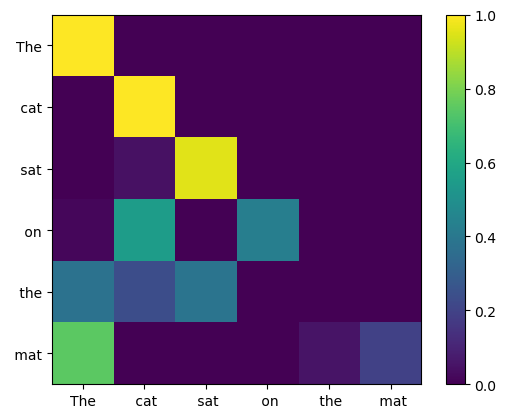

In [53]:
plt.imshow(softmaxed_masked_normalized_query_key_vectors,cmap="viridis")
plt.xticks(torch.arange(6),tokens)
plt.yticks(torch.arange(6),tokens)
plt.colorbar()